# Credit Fraud

In [2]:
import platform
import psutil
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from zipfile import ZipFile
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

# Definir uma semente global para garantir que os resultados iniciais sejam sempre os mesmos
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

data = pd.read_csv(r"creditcard.csv")

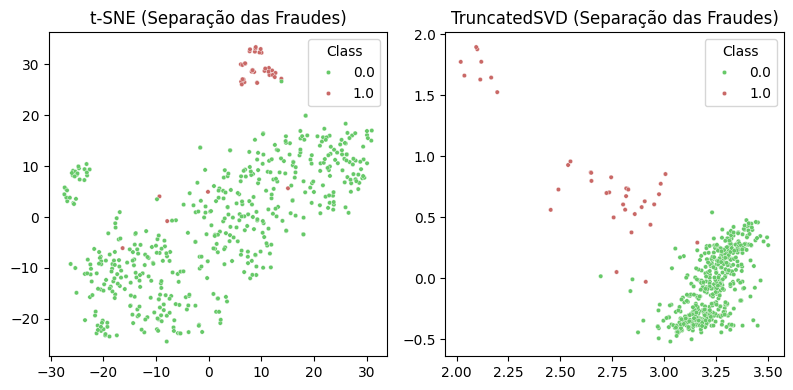

In [3]:
##PRÉ-PROCESSAMENTO: BALANCEAMENTO (UNDERSAMPLING) E REDUÇÃO

# Separa as transações que são Fraudes (Class == 1) das transações Normais (Class == 0)
data_class_1_balanceado = data[data['Class'] == 1]
data_class_0_balanceado = data[data['Class'] == 0]

# Como existem pouquíssimas fraudes, nós sorteamos aleatoriamente apenas 492 transações normais para que as duas classes fiquem com o mesmo tamanho
data_class_0_reduced_balanceado = data_class_0_balanceado.sample(n=492, random_state=1)

# Junta as duas metades (492 fraudes + 492 normais) em uma única tabela balanceada
data_balanceado = pd.concat([data_class_1_balanceado, data_class_0_reduced_balanceado], ignore_index=True)

# Separa o que é a variável alvo (Y = Fraude ou não) e o que são as características (X = Valor, tempo, etc)
X = data_balanceado.drop(['Class'], axis=1)
y = data_balanceado['Class']

# O MinMaxScaler pega valores que variam muito e os "espreme" para o intervalo entre 0 e 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# As técnicas de t-SNE e SVD pegam todas as 30 colunas do dataset e as resumem em apenas 2 colunas (2D)
# O objetivo não é treinar o modelo com isso, mas sim permitir que a gente consiga desenhar um gráfico 2D
tsne = TSNE(n_components=2, random_state=RANDOM_SEED)
X_tsne = tsne.fit_transform(X_scaled)

svd = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
X_svd = svd.fit_transform(X_scaled)

# PLOTAGEM DOS GRÁFICOS DE DISTRIBUIÇÃO

colors = ['#66c968', '#C96866'] # Verde para Normal, Vermelho para Fraude
plt.figure(figsize=(12, 4))

# Gráfico da esquerda: Distribuição vista pelo t-SNE
plt.subplot(1, 3, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette=colors, s=10)
plt.title('t-SNE (Separação das Fraudes)')

# Gráfico da direita: Distribuição vista pelo TruncatedSVD
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_svd[:, 0], y=X_svd[:, 1], hue=y, palette=colors, s=10)
plt.title('TruncatedSVD (Separação das Fraudes)')

# Ajusta o espaçamento para não sobrepor os títulos
plt.tight_layout()
plt.show()

In [4]:
##AMBIENTE COMPUTACIONAL
print("=== CONFIGURAÇÃO DO AMBIENTE ===")
print(f"Sistema Operacional: {platform.system()} {platform.release()}")
print(f"Processador: {platform.processor()}")
try:
    print(f"Memória RAM: {round(psutil.virtual_memory().total / (1024.0 **3))} GB")
except:
    print("Memória RAM: Não foi possível obter")
print(f"Versões - Python: {sys.version.split(' ')[0]} | Pandas: {pd.__version__} | Sklearn: {sklearn.__version__} | XGBoost: {xgb.__version__}\n")

=== CONFIGURAÇÃO DO AMBIENTE ===
Sistema Operacional: Linux 6.6.122+
Processador: x86_64
Memória RAM: 13 GB
Versões - Python: 3.12.13 | Pandas: 2.2.2 | Sklearn: 1.6.1 | XGBoost: 3.2.0



In [5]:

##EXECUÇÃO DOS MODELOS DE INTELIGÊNCIA ARTIFICIAL (30 RODADAS)
print("=== INICIANDO TREINAMENTO COM 4 MODELOS (30 EXECUÇÕES) ===")
n_execucoes = 30

# Listas para guardar as notas de todos os modelos
resultados_lr = []
resultados_xgb = []
resultados_rf = []
resultados_knn = []

sementes = np.random.randint(0, 10000, size=n_execucoes)

for semente in sementes:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=semente)

    # 1. Regressão Logística
    lr_model = LogisticRegression(max_iter=1000, random_state=semente)
    lr_model.fit(X_train, y_train)
    resultados_lr.append(f1_score(y_test, lr_model.predict(X_test)))

    # 2. XGBoost
    xgb_model = XGBClassifier(eval_metric='logloss', random_state=semente)
    xgb_model.fit(X_train, y_train)
    resultados_xgb.append(f1_score(y_test, xgb_model.predict(X_test)))

    # 3. Random Forest
    rf_model = RandomForestClassifier(random_state=semente)
    rf_model.fit(X_train, y_train)
    resultados_rf.append(f1_score(y_test, rf_model.predict(X_test)))

    # 4. K-Nearest Neighbors (KNN) - Não usa semente pois não tem aleatoriedade no treino
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    resultados_knn.append(f1_score(y_test, knn_model.predict(X_test)))

# Criando o DataFrame com os 4 modelos
df_resultados = pd.DataFrame({
    'Regressão Logística': resultados_lr,
    'XGBoost': resultados_xgb,
    'Random Forest': resultados_rf,
    'KNN': resultados_knn
})
print("Treinamento concluído!\n")

print("=== ESTATÍSTICAS DESCRITIVAS (F1-SCORE) ===")
# O sort_values vai ordenar a tabela pela média, do melhor modelo para o pior
estatisticas = df_resultados.agg(['mean', 'std', 'median']).T
display(estatisticas.sort_values(by='mean', ascending=False))

=== INICIANDO TREINAMENTO COM 4 MODELOS (30 EXECUÇÕES) ===
Treinamento concluído!

=== ESTATÍSTICAS DESCRITIVAS (F1-SCORE) ===


,mean,std,median
XGBoost,0.943885,0.035625,0.947368
Random Forest,0.939618,0.042472,0.947368
KNN,0.917261,0.055772,0.923077
Regressão Logística,0.910784,0.048741,0.916667


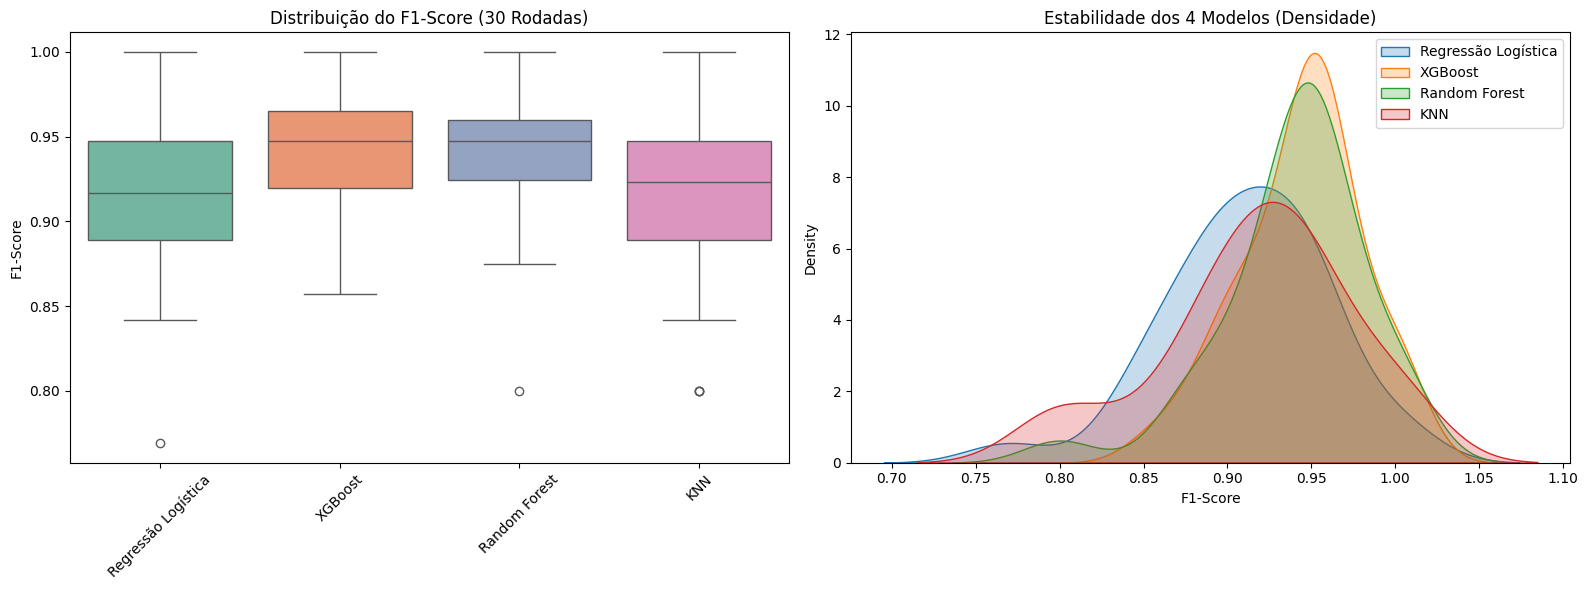


=== TESTE DE HIPÓTESE (TESTE T PAREADO) ===
Comparando o 1º Colocado (XGBoost) contra o 2º Colocado (Random Forest):
Estatística T: 0.5904 | P-Valor: 5.5952e-01
Conclusão: NÃO HÁ diferença estatística significativa.
Os modelos 'XGBoost' e 'Random Forest' tiveram um empate técnico.


In [6]:
# VISUALIZAÇÃO DOS RESULTADOS E TESTE DE HIPÓTESES

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: BOXPLOT MÚLTIPLO ---
sns.boxplot(data=df_resultados, palette="Set2", ax=ax[0])
ax[0].set_title('Distribuição do F1-Score (30 Rodadas)')
ax[0].set_ylabel('F1-Score')
ax[0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: CURVA DE DENSIDADE MULTICOLORIDA ---
sns.kdeplot(df_resultados['Regressão Logística'], fill=True, label='Regressão Logística', ax=ax[1])
sns.kdeplot(df_resultados['XGBoost'], fill=True, label='XGBoost', ax=ax[1])
sns.kdeplot(df_resultados['Random Forest'], fill=True, label='Random Forest', ax=ax[1])
sns.kdeplot(df_resultados['KNN'], fill=True, label='KNN', ax=ax[1])

ax[1].set_title('Estabilidade dos 4 Modelos (Densidade)')
ax[1].set_xlabel('F1-Score')
ax[1].legend()

plt.tight_layout()
plt.show()

# TESTE T-PAREADO (ENTRE O 1º E O 2º COLOCADO)
print("\n=== TESTE DE HIPÓTESE (TESTE T PAREADO) ===")

# Descobrindo automaticamente os dois melhores modelos pela média
medias = df_resultados.mean().sort_values(ascending=False)
melhor_modelo = medias.index[0]
segundo_melhor = medias.index[1]

print(f"Comparando o 1º Colocado ({melhor_modelo}) contra o 2º Colocado ({segundo_melhor}):")

stat, p_valor = stats.ttest_rel(df_resultados[melhor_modelo], df_resultados[segundo_melhor])

print(f"Estatística T: {stat:.4f} | P-Valor: {p_valor:.4e}")

if p_valor < 0.05:
    print(f"Conclusão: A diferença é ESTATISTICAMENTE SIGNIFICATIVA.")
    print(f"O modelo '{melhor_modelo}' é matematicamente superior ao '{segundo_melhor}'.")
else:
    print(f"Conclusão: NÃO HÁ diferença estatística significativa.")
    print(f"Os modelos '{melhor_modelo}' e '{segundo_melhor}' tiveram um empate técnico.")

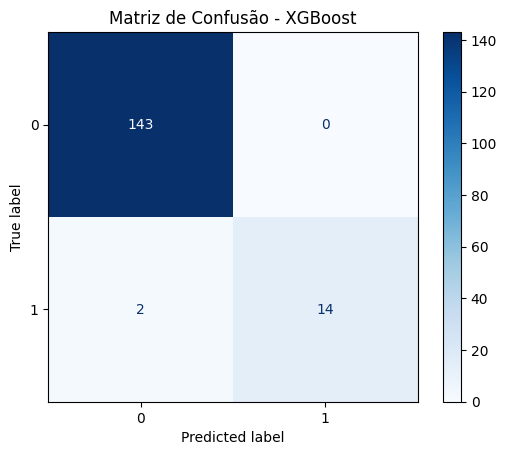

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

modelo_final = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

modelo_final.fit(X_train, y_train)

predicoes = modelo_final.predict(X_test)

cm = confusion_matrix(y_test, predicoes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - XGBoost")
plt.show()

In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       143
         1.0       1.00      0.88      0.93        16

    accuracy                           0.99       159
   macro avg       0.99      0.94      0.96       159
weighted avg       0.99      0.99      0.99       159



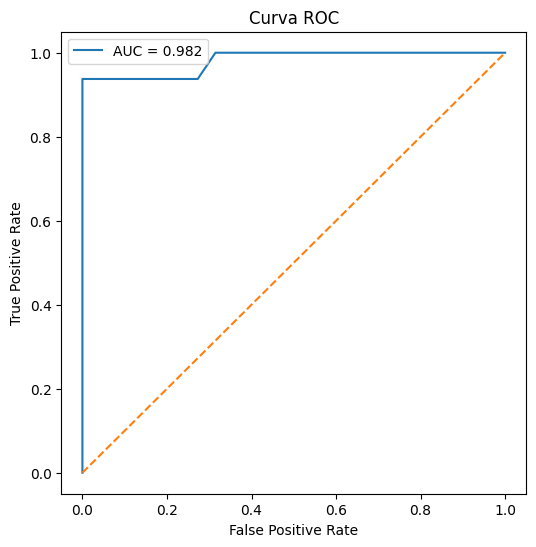

In [9]:
from sklearn.metrics import roc_curve, auc

probabilidades = modelo_final.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probabilidades)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend()

plt.show()

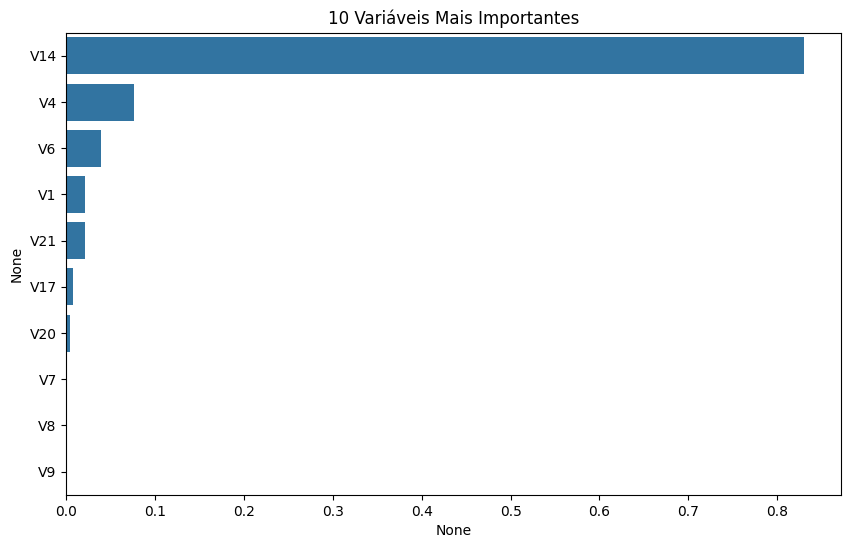

In [10]:
importances = pd.Series(
    modelo_final.feature_importances_,
    index=X.columns
)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importances.head(10),
    y=importances.head(10).index
)

plt.title("10 Variáveis Mais Importantes")

plt.show()

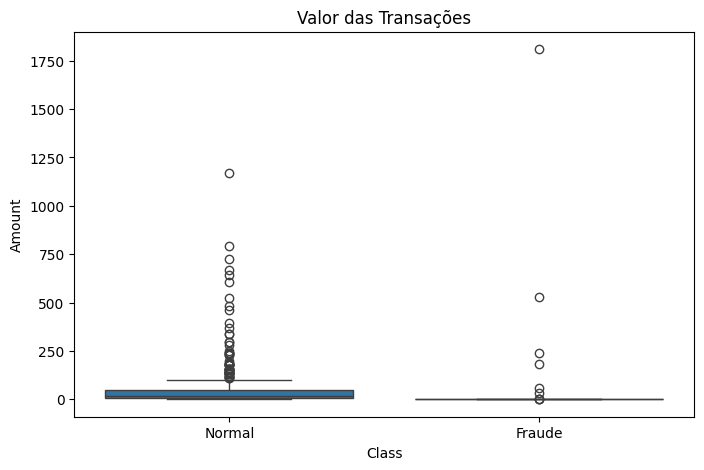

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=data_balanceado
)

plt.xticks([0,1],["Normal","Fraude"])

plt.title("Valor das Transações")

plt.show()

In [12]:
print("\nIntervalo de confiança (95%)")

for coluna in df_resultados.columns:

    media = df_resultados[coluna].mean()

    erro = stats.sem(df_resultados[coluna])

    ic = stats.t.interval(
        0.95,
        len(df_resultados[coluna])-1,
        loc=media,
        scale=erro
    )

    print(f"{coluna}")

    print(f"Média: {media:.4f}")

    print(f"IC95%: ({ic[0]:.4f}, {ic[1]:.4f})\n")


Intervalo de confiança (95%)
Regressão Logística
Média: 0.9108
IC95%: (0.8926, 0.9290)

XGBoost
Média: 0.9439
IC95%: (0.9306, 0.9572)

Random Forest
Média: 0.9396
IC95%: (0.9238, 0.9555)

KNN
Média: 0.9173
IC95%: (0.8964, 0.9381)



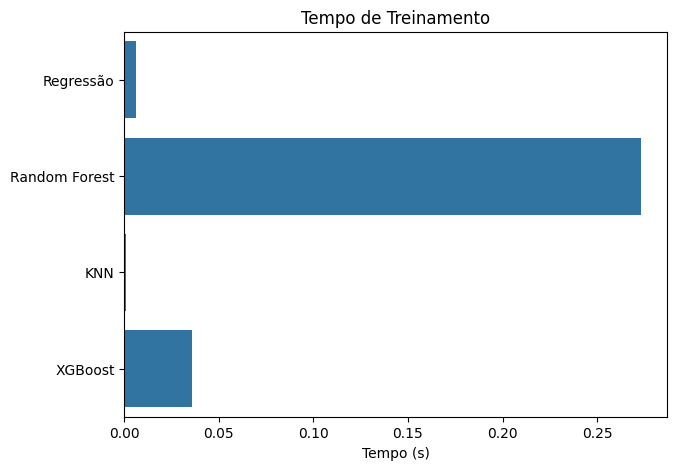

In [13]:
import time

tempos = {}

modelos = {
    "Regressão": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

for nome, modelo in modelos.items():

    inicio = time.time()

    modelo.fit(X_train, y_train)

    fim = time.time()

    tempos[nome] = fim - inicio

plt.figure(figsize=(7,5))

sns.barplot(
    x=list(tempos.values()),
    y=list(tempos.keys())
)

plt.xlabel("Tempo (s)")

plt.title("Tempo de Treinamento")

plt.show()